# 미국 ETF 절세 계좌 배분 전략 | 실전편

투자 조건을 입력하고 아래 코드 셀을 실행하세요. 연차별 원금 이동도,
10년 뒤 세후 성과표, 투자금별 실효세율 그래프를 생성합니다.



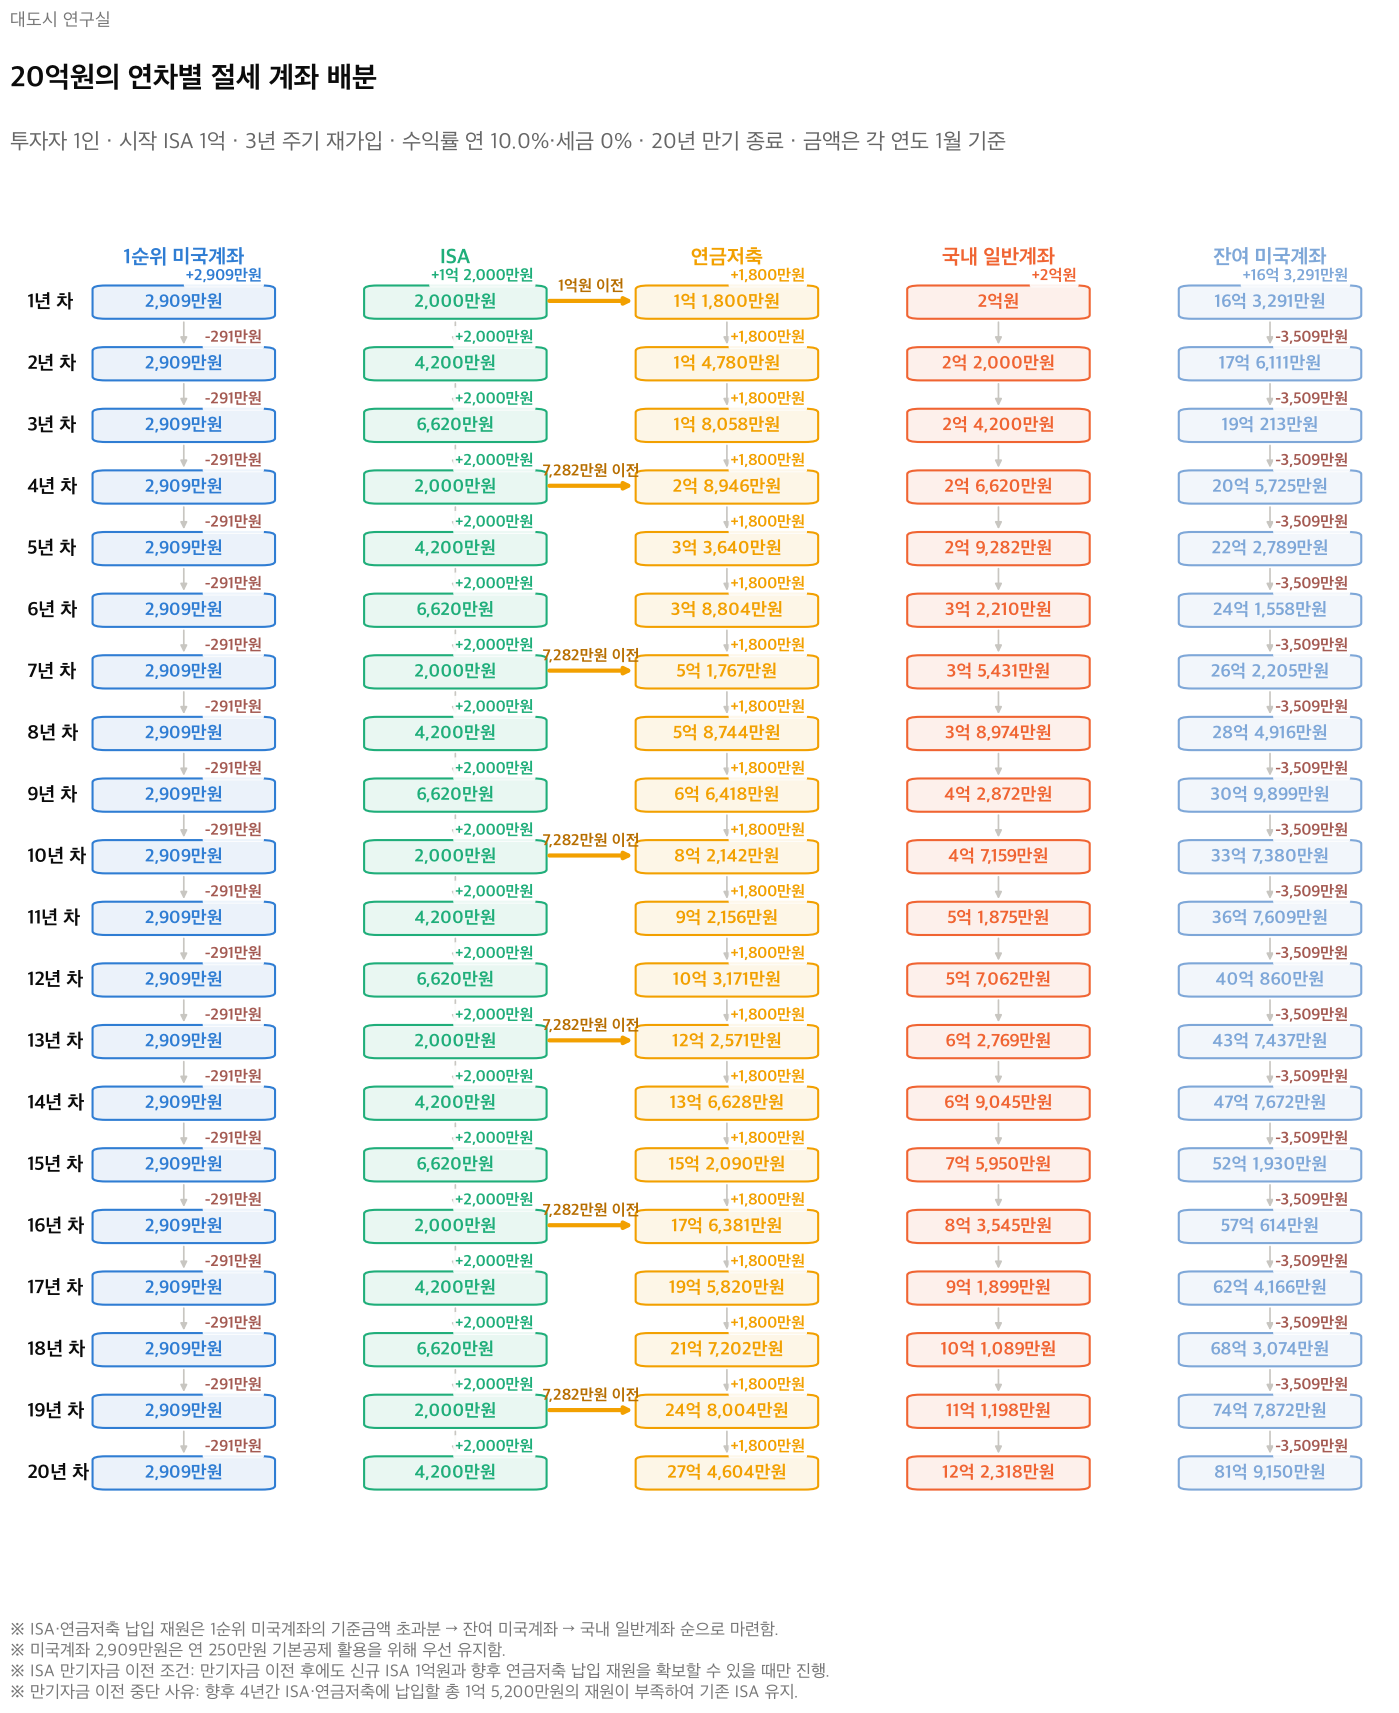


**20년 만기 청산 결과 · 연 10.0% 기준**

- 누적 납부세액: **22억 7,865만원**
- 세후 최종자산: **110억 5,258만원**


구분,세전,미국계좌,ISA 1억·재가입,ISA 1억·유지,신규 ISA·재가입,신규 ISA·유지
세전 최종자산,"134억 5,500만원","134억 5,500만원","134억 5,500만원","134억 5,500만원","134억 5,500만원","134억 5,500만원"
운용 중 납부세액,0원,0원,"9,788만원","3,678만원","9,788만원","4,062만원"
최종 청산세액,0원,25억 910만원,"21억 8,076만원","22억 7,553만원","22억 1,227만원","22억 8,190만원"
누적 납부세액,0원,25억 910만원,"22억 7,865만원","23억 1,231만원","23억 1,015만원","23억 2,252만원"
최종 세후자산,"134억 5,500만원","109억 4,590만원","110억 5,258만원",111억 128만원,"110억 2,108만원","110억 7,601만원"
세전 대비 감소액,0원,25억 910만원,24억 242만원,"23억 5,372만원","24억 3,392만원","23억 7,899만원"
실효세율,0.0%,21.9%,21.0%,20.5%,21.2%,20.8%


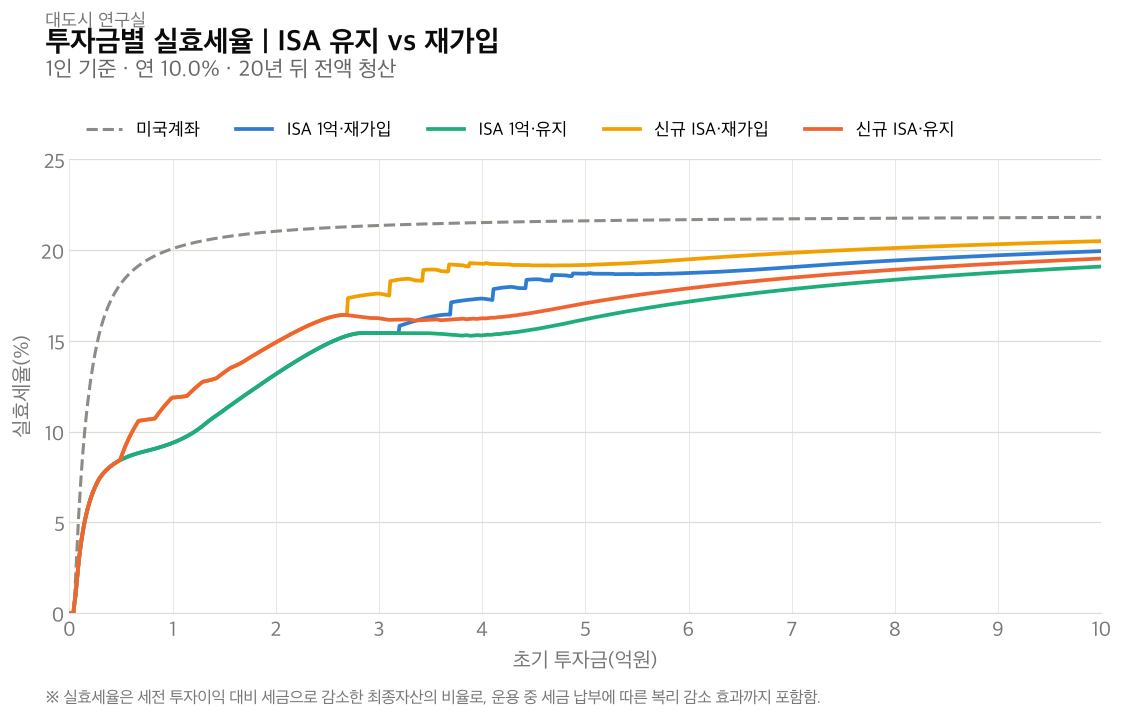

저장 완료: output/us_etf_account_allocation_flow.png
저장 완료: output/us_etf_effective_tax_rate_by_investment.png


In [ ]:
# @title 투자 조건을 입력하고 실행하세요
투자자 = "1인"  # @param ["1인", "부부"]
초기투자금_억원 = 4.0  # @param {type:"number", min:0.01, step:0.1}
투자기간_년 = 10  # @param {type:"integer", min:1, step:1}
연수익률_퍼센트 = 10  # @param {type:"number", min:0.1, step:0.5
시작시_ISA_누적한도_1억원 = True  # @param {type:"boolean"}
ISA_3년만기_연금이전후_재가입 = True  # @param {type:"boolean"}
실효세율_그래프_최대투자금_억원 = 10.0  # @param {type:"number", min:0.1, step:0.5}
실효세율_그래프_간격_만원 = 100  # @param {type:"integer", min:10, step:10}

"""미국 ETF 절세 계좌 배분 전략의 자금 이동과 세후 성과를 비교한다.

모든 계좌는 동일한 연 수익률로 복리 운용된다. ISA 만기자금은 세금을
정산한 후 세액공제 없이 연금계좌로 전액 이전한다. 분배금, 수수료,
환율, 종합과세 추가세율과 상품별 추적오차는 반영하지 않는다.
"""

import base64
from dataclasses import dataclass, replace
from importlib.util import find_spec
import math
from pathlib import Path
import subprocess
import sys
from tempfile import TemporaryDirectory
from typing import Optional
from urllib.request import urlopen

import matplotlib.pyplot as plt
from matplotlib import font_manager, patches
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display


WON_PER_MANWON = 10_000
WON_PER_EOK = 100_000_000

INVESTOR_COUNT = 1 if str(투자자) == "1인" else 2
INVESTOR_LABEL = str(투자자)
US_DEDUCTION_KRW = 2_500_000 * INVESTOR_COUNT
US_TAX_RATE = 0.22
GENERAL_TAX_RATE = 0.154
FINANCIAL_INCOME_LIMIT_KRW = 20_000_000 * INVESTOR_COUNT
ISA_ANNUAL_LIMIT_KRW = 20_000_000 * INVESTOR_COUNT
ISA_MAX_KRW = 100_000_000 * INVESTOR_COUNT
ISA_TERM_MONTHS = 36
ISA_EXEMPTION_KRW = 2_000_000 * INVESTOR_COUNT
ISA_TAX_RATE = 0.099
PENSION_ANNUAL_LIMIT_KRW = 18_000_000 * INVESTOR_COUNT
PENSION_TAX_RATE = 0.165

INITIAL_INVESTMENT_KRW = float(초기투자금_억원) * WON_PER_EOK
INVESTMENT_YEARS = int(투자기간_년)
RETURN_RATE = float(연수익률_퍼센트) / 100
CHART_MAX_KRW = float(실효세율_그래프_최대투자금_억원) * WON_PER_EOK
CHART_STEP_KRW = int(실효세율_그래프_간격_만원) * WON_PER_MANWON

US_FIRST_PRIORITY_KRW = (
    US_TAX_RATE * US_DEDUCTION_KRW
    - ISA_TAX_RATE * ISA_EXEMPTION_KRW
) / (RETURN_RATE * (US_TAX_RATE - ISA_TAX_RATE))
GENERAL_MAX_KRW = FINANCIAL_INCOME_LIMIT_KRW / RETURN_RATE

ACCOUNT_COLORS = {
    "1순위 미국계좌": "#2F7DD3",
    "ISA": "#1FAE7A",
    "연금저축": "#F2A000",
    "국내 일반계좌": "#F06432",
    "잔여 미국계좌": "#7EA7D8",
}
STRATEGY_COLORS = ("#2F7DD3", "#1FAE7A", "#F2A000", "#F06432")
BACKGROUND_COLOR = "#FFFFFF"
GRID_COLOR = "#DEDCD6"
TEXT_COLOR = "#0B0B0B"
SECONDARY_TEXT_COLOR = "#666666"
TICK_COLOR = "#777777"
GRAPH_TEXT_COLOR = "#64748B"


@dataclass
class Account:
    """계좌의 평가금액과 세금 계산용 원금을 보관한다."""

    value_krw: float = 0.0
    basis_krw: float = 0.0


@dataclass
class Portfolio:
    """절세 계좌 배분 전략의 상태를 보관한다."""

    us_core: Account
    isa: Account
    pension: Account
    general: Account
    us_residual: Account
    isa_age_months: int = 0
    renewal_active: bool = False
    taxes_paid_krw: float = 0.0
    us_deduction_remaining_krw: float = US_DEDUCTION_KRW


def validate_inputs() -> None:
    """사용자 입력값의 범위를 확인한다."""
    if INITIAL_INVESTMENT_KRW <= 0:
        raise ValueError("초기투자금은 0원보다 커야 합니다.")
    if INVESTMENT_YEARS < 1:
        raise ValueError("투자기간은 1년 이상이어야 합니다.")
    if not 0 < RETURN_RATE < 1:
        raise ValueError("연수익률은 0%보다 크고 100%보다 작아야 합니다.")
    if CHART_MAX_KRW <= 0 or CHART_STEP_KRW <= 0:
        raise ValueError("그래프 최대투자금과 간격은 0보다 커야 합니다.")


def select_font() -> str:
    """설치된 한글 글꼴 중 우선순위가 가장 높은 글꼴을 선택한다."""
    macos_font_path = Path("/System/Library/Fonts/AppleSDGothicNeo.ttc")
    if macos_font_path.exists():
        font_manager.fontManager.addfont(macos_font_path)

    candidates = (
        "Pretendard",
        "Apple SD Gothic Neo",
        "Noto Sans CJK KR",
        "Malgun Gothic",
    )
    installed = {font.name for font in font_manager.fontManager.ttflist}
    return next((font for font in candidates if font in installed), "DejaVu Sans")


def format_korean_currency(amount_krw: float) -> str:
    """원화 금액을 억원·만원 단위로 표시한다."""
    rounded = int(round(max(amount_krw, 0.0) / WON_PER_MANWON)) * WON_PER_MANWON
    eok, remainder = divmod(rounded, WON_PER_EOK)
    manwon = remainder // WON_PER_MANWON
    parts = []
    if eok:
        parts.append(f"{eok:,}억")
    if manwon:
        parts.append(f"{manwon:,}만")
    return " ".join(parts) + "원" if parts else "0원"


def clone_portfolio(portfolio: Portfolio) -> Portfolio:
    """계좌 상태를 깊은 복사한다."""
    return Portfolio(
        us_core=replace(portfolio.us_core),
        isa=replace(portfolio.isa),
        pension=replace(portfolio.pension),
        general=replace(portfolio.general),
        us_residual=replace(portfolio.us_residual),
        isa_age_months=portfolio.isa_age_months,
        renewal_active=portfolio.renewal_active,
        taxes_paid_krw=portfolio.taxes_paid_krw,
        us_deduction_remaining_krw=portfolio.us_deduction_remaining_krw,
    )


def add_principal(account: Account, amount_krw: float) -> float:
    """계좌에 원금을 추가하고 실제 납입액을 반환한다."""
    amount_krw = max(amount_krw, 0.0)
    account.value_krw += amount_krw
    account.basis_krw += amount_krw
    return amount_krw


def take_initial_cash(remaining_krw: float, target_krw: float) -> tuple[float, float]:
    """초기 현금에서 목표금액까지 배분한다."""
    allocated_krw = min(max(remaining_krw, 0.0), max(target_krw, 0.0))
    return allocated_krw, remaining_krw - allocated_krw


def initialize_portfolio(
    initial_krw: float,
    has_accumulated_isa: bool,
    renew_isa: bool,
) -> tuple[Portfolio, list[str]]:
    """절세 우선순위대로 1년 차 1월의 원금을 배분한다."""
    portfolio = Portfolio(
        us_core=Account(),
        isa=Account(),
        pension=Account(),
        general=Account(),
        us_residual=Account(),
        renewal_active=renew_isa,
    )
    events = []
    initial_transfer_done = False
    remaining_krw = initial_krw

    amount_krw, remaining_krw = take_initial_cash(
        remaining_krw, US_FIRST_PRIORITY_KRW
    )
    add_principal(portfolio.us_core, amount_krw)

    if has_accumulated_isa:
        amount_krw, remaining_krw = take_initial_cash(remaining_krw, ISA_MAX_KRW)
        reserve_after_rejoining_krw = 4 * (
            ISA_ANNUAL_LIMIT_KRW + PENSION_ANNUAL_LIMIT_KRW
        )
        required_if_transferred_krw = (
            ISA_MAX_KRW
            + ISA_ANNUAL_LIMIT_KRW
            + PENSION_ANNUAL_LIMIT_KRW
            + reserve_after_rejoining_krw
        )
        can_transfer_initial_isa = (
            renew_isa
            and remaining_krw + amount_krw >= required_if_transferred_krw
        )
        if can_transfer_initial_isa:
            initial_transfer_done = True
            add_principal(portfolio.pension, amount_krw)
            amount_krw, remaining_krw = take_initial_cash(
                remaining_krw, ISA_ANNUAL_LIMIT_KRW
            )
            add_principal(portfolio.isa, amount_krw)
            portfolio.isa_age_months = 0
        else:
            portfolio.renewal_active = False
            add_principal(portfolio.isa, amount_krw)
            portfolio.isa_age_months = ISA_TERM_MONTHS
            if renew_isa:
                events.append("재원 확보를 위해 ISA 이전 중단 → 기존 ISA 유지")
    else:
        amount_krw, remaining_krw = take_initial_cash(
            remaining_krw, ISA_ANNUAL_LIMIT_KRW
        )
        add_principal(portfolio.isa, amount_krw)
        portfolio.isa_age_months = 0

    amount_krw, remaining_krw = take_initial_cash(
        remaining_krw, PENSION_ANNUAL_LIMIT_KRW
    )
    add_principal(portfolio.pension, amount_krw)
    if initial_transfer_done:
        events.append(
            f"기존 ISA {format_korean_currency(portfolio.pension.basis_krw - amount_krw)} → 연금저축"
            f" · ISA 재가입 +{format_korean_currency(portfolio.isa.basis_krw)}"
            f" · 연금저축 +{format_korean_currency(amount_krw)}"
        )
    amount_krw, remaining_krw = take_initial_cash(remaining_krw, GENERAL_MAX_KRW)
    add_principal(portfolio.general, amount_krw)
    add_principal(portfolio.us_residual, remaining_krw)
    return portfolio, events


def unrealized_gain_ratio(account: Account) -> float:
    """평가금액 중 미실현이익의 비율을 반환한다."""
    if account.value_krw <= 0:
        return 0.0
    gain_krw = max(account.value_krw - account.basis_krw, 0.0)
    return gain_krw / account.value_krw


def sell_for_net(
    account: Account,
    desired_net_krw: float,
    tax_rate: float,
    deduction_remaining_krw: float = 0.0,
    max_gross_krw: Optional[float] = None,
) -> tuple[float, float, float]:
    """세후 목표금액을 마련하도록 매도하고 세금·공제잔액을 반환한다."""
    available_gross_krw = account.value_krw
    if max_gross_krw is not None:
        available_gross_krw = min(
            available_gross_krw,
            max(max_gross_krw, 0.0),
        )
    desired_net_krw = min(max(desired_net_krw, 0.0), available_gross_krw)
    if desired_net_krw <= 0:
        return 0.0, 0.0, deduction_remaining_krw

    gain_ratio = unrealized_gain_ratio(account)
    untaxed_gross_krw = (
        deduction_remaining_krw / gain_ratio if gain_ratio > 0 else math.inf
    )
    if desired_net_krw <= untaxed_gross_krw:
        gross_krw = desired_net_krw
    else:
        denominator = 1 - tax_rate * gain_ratio
        gross_krw = (
            desired_net_krw - tax_rate * deduction_remaining_krw
        ) / denominator
    gross_krw = min(gross_krw, available_gross_krw)
    realized_gain_krw = gross_krw * gain_ratio
    taxable_gain_krw = max(realized_gain_krw - deduction_remaining_krw, 0.0)
    tax_krw = taxable_gain_krw * tax_rate
    used_deduction_krw = min(realized_gain_krw, deduction_remaining_krw)
    basis_sold_krw = gross_krw - realized_gain_krw
    account.value_krw = max(account.value_krw - gross_krw, 0.0)
    account.basis_krw = max(account.basis_krw - basis_sold_krw, 0.0)
    return gross_krw - tax_krw, tax_krw, deduction_remaining_krw - used_deduction_krw


def available_funding_krw(portfolio: Portfolio) -> float:
    """향후 ISA·연금 납입에 사용할 하위 순위 자금을 반환한다."""
    us_core_excess_krw = max(
        portfolio.us_core.value_krw - US_FIRST_PRIORITY_KRW,
        0.0,
    )
    return (
        us_core_excess_krw
        + portfolio.us_residual.value_krw
        + portfolio.general.value_krw
    )


def reserve_needed_to_fill_final_isa(
    portfolio: Portfolio,
    assume_isa_closed: bool = False,
) -> float:
    """마지막 ISA 1억원과 동일 기간의 연금 납입에 필요한 금액을 계산한다."""
    current_isa_basis_krw = 0.0 if assume_isa_closed else portfolio.isa.basis_krw
    isa_shortfall_krw = max(ISA_MAX_KRW - current_isa_basis_krw, 0.0)
    years_to_fill = math.ceil(isa_shortfall_krw / ISA_ANNUAL_LIMIT_KRW)
    return years_to_fill * (
        ISA_ANNUAL_LIMIT_KRW + PENSION_ANNUAL_LIMIT_KRW
    )


def should_stop_isa_renewal(
    portfolio: Portfolio,
    assume_isa_closed: bool = False,
) -> bool:
    """마지막 ISA를 1억원까지 채우기 위해 만기이전을 중지할지 판단한다."""
    reserve_krw = reserve_needed_to_fill_final_isa(
        portfolio,
        assume_isa_closed,
    )
    return reserve_krw > 0 and available_funding_krw(portfolio) <= reserve_krw


def fund_from_lower_priority_accounts(
    portfolio: Portfolio,
    target_net_krw: float,
    us_deduction_remaining_krw: float,
    apply_tax: bool,
) -> tuple[float, float]:
    """1순위 미국계좌 초과분, 잔여 미국계좌, 일반계좌 순으로 마련한다."""
    remaining_krw = max(target_net_krw, 0.0)
    funded_krw = 0.0
    for account, tax_rate, use_deduction, protected_krw in (
        (portfolio.us_core, US_TAX_RATE, True, US_FIRST_PRIORITY_KRW),
        (portfolio.us_residual, US_TAX_RATE, True, 0.0),
        (portfolio.general, GENERAL_TAX_RATE, False, 0.0),
    ):
        if remaining_krw <= 0:
            break
        if not apply_tax:
            available_krw = max(account.value_krw - protected_krw, 0.0)
            amount_krw = min(remaining_krw, available_krw)
            account.value_krw -= amount_krw
            account.basis_krw = max(account.basis_krw - amount_krw, 0.0)
            net_krw = amount_krw
            tax_krw = 0.0
        else:
            deduction_krw = us_deduction_remaining_krw if use_deduction else 0.0
            net_krw, tax_krw, deduction_left_krw = sell_for_net(
                account,
                remaining_krw,
                tax_rate,
                deduction_krw,
                max(account.value_krw - protected_krw, 0.0),
            )
            if use_deduction:
                us_deduction_remaining_krw = deduction_left_krw
            portfolio.taxes_paid_krw += tax_krw
        funded_krw += net_krw
        remaining_krw -= net_krw
    return funded_krw, us_deduction_remaining_krw


def close_isa_to_pension(portfolio: Portfolio, apply_tax: bool) -> tuple[float, float]:
    """ISA를 해지하고 세후 잔액 전액을 연금계좌로 이전한다."""
    gain_krw = max(portfolio.isa.value_krw - portfolio.isa.basis_krw, 0.0)
    tax_krw = (
        max(gain_krw - ISA_EXEMPTION_KRW, 0.0) * ISA_TAX_RATE
        if apply_tax
        else 0.0
    )
    transfer_krw = max(portfolio.isa.value_krw - tax_krw, 0.0)
    portfolio.taxes_paid_krw += tax_krw
    add_principal(portfolio.pension, transfer_krw)
    portfolio.isa = Account()
    portfolio.isa_age_months = 0
    return transfer_krw, tax_krw


def process_january(
    portfolio: Portfolio,
    year: int,
    apply_tax: bool,
) -> list[str]:
    """해당 연도 1월의 ISA 만기이전·재가입과 절세계좌 납입을 처리한다."""
    events = []
    portfolio.us_deduction_remaining_krw = US_DEDUCTION_KRW
    us_deduction_remaining_krw = portfolio.us_deduction_remaining_krw

    # 마지막 ISA를 1억원까지 채우면서 같은 기간의 연금 일반 납입도
    # 계속할 수 있도록 필요금액을 미리 확보한다. 예를 들어 현재 ISA
    # 원금이 2천만원이면 4년간 ISA 8천만원과 연금 7천200만원,
    # 총 1억5천200만원이 필요하므로 가용 자금이 이 금액 이하면 만기이전을 중지한다.
    isa_is_mature = portfolio.isa_age_months >= ISA_TERM_MONTHS
    if portfolio.renewal_active and should_stop_isa_renewal(
        portfolio,
        assume_isa_closed=isa_is_mature,
    ):
        portfolio.renewal_active = False
        events.append("재원 확보를 위해 ISA 이전 중단 → 기존 ISA 유지")

    if (
        portfolio.renewal_active
        and isa_is_mature
        and portfolio.isa.value_krw > 0
    ):
        transfer_krw, _ = close_isa_to_pension(portfolio, apply_tax)
        events.append(f"ISA 만기 이전 → 연금저축")

    isa_room_krw = max(ISA_MAX_KRW - portfolio.isa.basis_krw, 0.0)
    isa_target_krw = min(ISA_ANNUAL_LIMIT_KRW, isa_room_krw)
    funded_krw, us_deduction_remaining_krw = fund_from_lower_priority_accounts(
        portfolio,
        isa_target_krw,
        us_deduction_remaining_krw,
        apply_tax,
    )
    add_principal(portfolio.isa, funded_krw)
    if funded_krw:
        isa_event = (
            f"ISA 재가입 +{format_korean_currency(funded_krw)}"
            if "ISA 만기 이전 → 연금저축" in events
            else f"ISA +{format_korean_currency(funded_krw)}"
        )
        events.append(isa_event)

    (
        pension_funded_krw,
        us_deduction_remaining_krw,
    ) = fund_from_lower_priority_accounts(
        portfolio,
        PENSION_ANNUAL_LIMIT_KRW,
        us_deduction_remaining_krw,
        apply_tax,
    )
    add_principal(portfolio.pension, pension_funded_krw)
    if pension_funded_krw:
        events.append(f"연금저축 +{format_korean_currency(pension_funded_krw)}")
    portfolio.us_deduction_remaining_krw = us_deduction_remaining_krw
    return events


def apply_annual_return(portfolio: Portfolio, return_rate: float) -> None:
    """모든 계좌에 연간 수익률을 적용한다."""
    for account in (
        portfolio.us_core,
        portfolio.isa,
        portfolio.pension,
        portfolio.general,
        portfolio.us_residual,
    ):
        account.value_krw *= 1 + return_rate
    portfolio.isa_age_months += 12


def harvest_us_deduction(portfolio: Portfolio) -> None:
    """해당 연도에 남은 미국계좌 기본공제 범위에서 취득원가를 높인다."""
    deduction_remaining_krw = portfolio.us_deduction_remaining_krw
    for account in (portfolio.us_core, portfolio.us_residual):
        gain_krw = max(account.value_krw - account.basis_krw, 0.0)
        harvested_krw = min(gain_krw, deduction_remaining_krw)
        account.basis_krw += harvested_krw
        deduction_remaining_krw -= harvested_krw
        if deduction_remaining_krw <= 0:
            break
    portfolio.us_deduction_remaining_krw = deduction_remaining_krw


def snapshot(portfolio: Portfolio, year_label: str, events: list[str]) -> dict:
    """흐름도용 계좌별 원금 상태를 반환한다."""
    return {
        "시점": year_label,
        "1순위 미국계좌": portfolio.us_core.value_krw,
        "ISA": portfolio.isa.value_krw,
        "연금저축": portfolio.pension.value_krw,
        "국내 일반계좌": portfolio.general.value_krw,
        "잔여 미국계좌": portfolio.us_residual.value_krw,
        "이동": " · ".join(events) if events else "-",
    }


def simulate_allocation_flow(
    initial_krw: float,
    years: int,
    has_accumulated_isa: bool,
    renew_isa: bool,
    reflect_return: bool = False,
    return_rate: float = 0.0,
) -> pd.DataFrame:
    """연차별 계좌 이동을 계산하며 선택 시 평가수익을 반영한다."""
    portfolio, initial_events = initialize_portfolio(
        initial_krw, has_accumulated_isa, renew_isa
    )
    rows = [snapshot(portfolio, "1년 차", initial_events)]
    if portfolio.general.value_krw <= 1:
        return pd.DataFrame(rows)
    for year in range(2, 101):
        if reflect_return:
            apply_annual_return(portfolio, return_rate)
        else:
            portfolio.isa_age_months += 12
        events = process_january(portfolio, year, apply_tax=False)
        rows.append(snapshot(portfolio, f"{year}년 차", events))
        if portfolio.general.value_krw <= 1:
            break
    return pd.DataFrame(rows)


def simulate_strategy(
    initial_krw: float,
    years: int,
    return_rate: float,
    has_accumulated_isa: bool,
    renew_isa: bool,
) -> dict[str, float]:
    """절세 계좌 배분 전략의 세후 종료자산과 누적세금을 계산한다."""
    portfolio, _ = initialize_portfolio(
        initial_krw, has_accumulated_isa, renew_isa
    )
    for year in range(1, years + 1):
        if year > 1:
            process_january(portfolio, year, apply_tax=True)
        apply_annual_return(portfolio, return_rate)
        if year < years:
            harvest_us_deduction(portfolio)

    us_gain_krw = sum(
        max(account.value_krw - account.basis_krw, 0.0)
        for account in (portfolio.us_core, portfolio.us_residual)
    )
    us_tax_krw = max(
        us_gain_krw - portfolio.us_deduction_remaining_krw,
        0.0,
    ) * US_TAX_RATE
    general_gain_krw = max(
        portfolio.general.value_krw - portfolio.general.basis_krw, 0.0
    )
    general_tax_krw = general_gain_krw * GENERAL_TAX_RATE
    isa_gain_krw = max(portfolio.isa.value_krw - portfolio.isa.basis_krw, 0.0)
    isa_tax_krw = max(isa_gain_krw - ISA_EXEMPTION_KRW, 0.0) * ISA_TAX_RATE
    pension_gain_krw = max(
        portfolio.pension.value_krw - portfolio.pension.basis_krw, 0.0
    )
    pension_tax_krw = pension_gain_krw * PENSION_TAX_RATE
    final_tax_krw = (
        us_tax_krw + general_tax_krw + isa_tax_krw + pension_tax_krw
    )
    gross_assets_krw = sum(
        account.value_krw
        for account in (
            portfolio.us_core,
            portfolio.isa,
            portfolio.pension,
            portfolio.general,
            portfolio.us_residual,
        )
    )
    pretax_final_krw = initial_krw * (1 + return_rate) ** years
    pretax_profit_krw = pretax_final_krw - initial_krw
    total_tax_krw = portfolio.taxes_paid_krw + final_tax_krw
    after_tax_final_krw = gross_assets_krw - final_tax_krw
    asset_reduction_krw = pretax_final_krw - after_tax_final_krw
    return {
        "세전 최종자산": pretax_final_krw,
        "운용 중 납부세액": portfolio.taxes_paid_krw,
        "최종 청산세액": final_tax_krw,
        "누적 납부세액": total_tax_krw,
        "최종 세후자산": after_tax_final_krw,
        "실효세율": asset_reduction_krw / pretax_profit_krw if pretax_profit_krw > 0 else np.nan,
    }


def simulate_us_only(initial_krw: float, years: int, return_rate: float) -> dict[str, float]:
    """미국계좌 100% 투자의 세후 성과를 계산한다."""
    account = Account(initial_krw, initial_krw)
    for year in range(1, years + 1):
        account.value_krw *= 1 + return_rate
        if year < years:
            gain_krw = max(account.value_krw - account.basis_krw, 0.0)
            account.basis_krw += min(gain_krw, US_DEDUCTION_KRW)
    gain_krw = max(account.value_krw - account.basis_krw, 0.0)
    tax_krw = max(gain_krw - US_DEDUCTION_KRW, 0.0) * US_TAX_RATE
    pretax_final_krw = initial_krw * (1 + return_rate) ** years
    pretax_profit_krw = pretax_final_krw - initial_krw
    return {
        "세전 최종자산": pretax_final_krw,
        "운용 중 납부세액": 0.0,
        "최종 청산세액": tax_krw,
        "누적 납부세액": tax_krw,
        "최종 세후자산": account.value_krw - tax_krw,
        "실효세율": tax_krw / pretax_profit_krw if pretax_profit_krw > 0 else np.nan,
    }


def strategy_name(has_accumulated_isa: bool, renew_isa: bool) -> str:
    """ISA 입력 조합을 짧은 전략명으로 표시한다."""
    start_label = (
        f"시작 ISA {format_korean_currency(ISA_MAX_KRW).removesuffix('원')}"
        if has_accumulated_isa
        else "신규 ISA"
    )
    renewal_label = "3년 주기 재가입" if renew_isa else "만기이전 없음"
    return f"{start_label} · {renewal_label}"


STRATEGIES = tuple(
    (strategy_name(has_isa, renew), has_isa, renew)
    for has_isa, renew in ((True, True), (True, False), (False, True), (False, False))
)


def calculate_performance_table() -> pd.DataFrame:
    """세전·미국계좌·네 가지 배분 전략의 성과표를 만든다."""
    columns = {
        "세전": {
            "세전 최종자산": INITIAL_INVESTMENT_KRW * (1 + RETURN_RATE) ** INVESTMENT_YEARS,
            "운용 중 납부세액": 0.0,
            "최종 청산세액": 0.0,
            "누적 납부세액": 0.0,
            "최종 세후자산": INITIAL_INVESTMENT_KRW * (1 + RETURN_RATE) ** INVESTMENT_YEARS,
            "실효세율": 0.0,
        },
        "미국계좌 100%": simulate_us_only(
            INITIAL_INVESTMENT_KRW, INVESTMENT_YEARS, RETURN_RATE
        ),
    }
    for name, has_isa, renew in STRATEGIES:
        columns[name] = simulate_strategy(
            INITIAL_INVESTMENT_KRW,
            INVESTMENT_YEARS,
            RETURN_RATE,
            has_isa,
            renew,
        )
    return pd.DataFrame(columns)


def style_axes(ax) -> None:
    """공통 그래프 축 스타일을 적용한다."""
    ax.set_facecolor(BACKGROUND_COLOR)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.9)
    ax.grid(axis="x", visible=False)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.tick_params(axis="both", colors=TICK_COLOR, labelsize=15, length=0)


def add_figure_header(
    fig,
    title: str,
    subtitle: str,
    brand_y: float = 0.975,
    title_y: float = 0.94,
    subtitle_y: float = 0.905,
) -> None:
    """그래프에 브랜드·제목·부제를 추가한다."""
    fig.text(0.08, brand_y, "대도시 연구실", fontsize=13, color=GRAPH_TEXT_COLOR)
    fig.text(0.08, title_y, title, fontsize=21, fontweight="bold", color=GRAPH_TEXT_COLOR)
    fig.text(0.08, subtitle_y, subtitle, fontsize=16, color=GRAPH_TEXT_COLOR)


def create_allocation_flow_chart(flow_df: pd.DataFrame):
    """계좌별 연차 잔액과 자금 이동을 세로 흐름도로 만든다."""
    accounts = tuple(ACCOUNT_COLORS)
    account_x = {account: index * 1.25 for index, account in enumerate(accounts)}
    row_count = len(flow_df)
    fig_height = max(7.5, 2.0 + row_count * 0.78)
    fig, ax = plt.subplots(figsize=(15.5, fig_height))
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    ax.set_xlim(-0.8, account_x[accounts[-1]] + 0.55)
    ax.set_ylim(row_count - 0.35, -1.2)
    ax.axis("off")
    for account in accounts:
        x = account_x[account]
        ax.text(
            x,
            -0.72,
            account,
            ha="center",
            va="center",
            fontsize=15,
            fontweight="bold",
            color=ACCOUNT_COLORS[account],
        )
    for row_index, row in flow_df.iterrows():
        initial_transfer_event = (
            row_index == 0 and "기존 ISA" in row["이동"]
            and "→ 연금저축" in row["이동"]
        )
        transfer_event = "ISA 만기 이전 →" in row["이동"]
        stop_event = "ISA 이전 중단" in row["이동"]
        ax.text(
            -0.72,
            row_index,
            row["시점"],
            ha="left",
            va="center",
            fontsize=14,
            fontweight="bold",
            color=TEXT_COLOR,
        )
        for account in accounts:
            x = account_x[account]
            value_krw = float(row[account])
            box = patches.FancyBboxPatch(
                (x - 0.39, row_index - 0.24),
                0.78,
                0.48,
                boxstyle="round,pad=0.03,rounding_size=0.06",
                facecolor=ACCOUNT_COLORS[account] + "18",
                edgecolor=ACCOUNT_COLORS[account],
                linewidth=1.5,
            )
            ax.add_patch(box)
            ax.text(
                x,
                row_index,
                format_korean_currency(value_krw),
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
                color=ACCOUNT_COLORS[account],
            )
            if row_index == 0:
                first_allocation_krw = {
                    "1순위 미국계좌": value_krw,
                    "ISA": (
                        ISA_MAX_KRW + value_krw
                        if (
                            bool(시작시_ISA_누적한도_1억원)
                            and initial_transfer_event
                        )
                        else value_krw
                    ),
                    "연금저축": min(PENSION_ANNUAL_LIMIT_KRW, value_krw),
                    "국내 일반계좌": value_krw,
                    "잔여 미국계좌": value_krw,
                }[account]
                change_krw = first_allocation_krw
            else:
                previous_row = flow_df.iloc[row_index - 1]
                growth_factor = 1.0
                previous_krw = float(previous_row[account]) * growth_factor
                transfer_krw = (
                    float(previous_row["ISA"]) * growth_factor
                    if transfer_event
                    else 0.0
                )
                if account == "ISA" and transfer_event:
                    change_krw = value_krw
                elif account == "연금저축" and transfer_event:
                    change_krw = min(
                        PENSION_ANNUAL_LIMIT_KRW,
                        max(value_krw - previous_krw - transfer_krw, 0.0),
                    )
                else:
                    change_krw = value_krw - previous_krw
            if abs(change_krw) >= WON_PER_MANWON / 2:
                change_label = (
                    "+" + format_korean_currency(change_krw)
                    if change_krw > 0
                    else "-" + format_korean_currency(abs(change_krw))
                )
                ax.text(
                    x + 0.36,
                    row_index - 0.27,
                    change_label,
                    ha="right",
                    va="bottom",
                    fontsize=11.5,
                    fontweight="bold",
                    color=(
                        ACCOUNT_COLORS[account]
                        if change_krw > 0
                        else "#A45A52"
                    ),
                    bbox={
                        "boxstyle": "round,pad=0.12",
                        "facecolor": "#FFFFFF",
                        "edgecolor": "none",
                        "alpha": 0.92,
                    },
                    zorder=5,
                )
            if row_index < row_count - 1:
                ax.annotate(
                    "",
                    xy=(x, row_index + 0.73),
                    xytext=(x, row_index + 0.28),
                    arrowprops={"arrowstyle": "-|>", "color": "#C8C6C1", "lw": 1.2},
                )
        if initial_transfer_event:
            ax.annotate(
                "",
                xy=(2.08, row_index - 0.02),
                xytext=(1.67, row_index - 0.02),
                arrowprops={
                    "arrowstyle": "-|>",
                    "color": "#F2A000",
                    "lw": 3.0,
                },
                zorder=4,
            )
            ax.text(
                1.875,
                row_index - 0.10,
                f"{format_korean_currency(ISA_MAX_KRW)} 이전",
                ha="center",
                va="bottom",
                fontsize=11.5,
                fontweight="bold",
                color="#B76E00",
            )
        elif transfer_event:
            growth_factor = 1.0
            transfer_krw = (
                float(flow_df.iloc[row_index - 1]["ISA"]) * growth_factor
            )
            ax.annotate(
                "",
                xy=(2.08, row_index - 0.02),
                xytext=(1.67, row_index - 0.02),
                arrowprops={
                    "arrowstyle": "-|>",
                    "color": "#F2A000",
                    "lw": 3.0,
                },
                zorder=4,
            )
            ax.text(
                1.875,
                row_index - 0.10,
                f"{format_korean_currency(transfer_krw)} 이전",
                ha="center",
                va="bottom",
                fontsize=11.5,
                fontweight="bold",
                color="#B76E00",
            )
        elif stop_event:
            ax.text(
                account_x["ISA"] - 0.48,
                row_index,
                "만기 이전\n중단·유지",
                ha="center",
                va="center",
                fontsize=10.5,
                fontweight="bold",
                color="#B76E00",
                bbox={
                    "boxstyle": "round,pad=0.24",
                    "facecolor": "#FFF7E6",
                    "edgecolor": "#F59E0B",
                },
                zorder=4,
            )

    strategy_label = strategy_name(
        bool(시작시_ISA_누적한도_1억원),
        bool(ISA_3년만기_연금이전후_재가입),
    )
    add_figure_header(
        fig,
        f"{format_korean_currency(INITIAL_INVESTMENT_KRW)}의 연차별 절세 계좌 배분",
        f"투자자 {INVESTOR_LABEL} · {strategy_label} · 수익률·세금 0% · 분배 종료까지 · 금액은 각 연도 1월 기준",
    )
    fig.text(
        0.08,
        0.025,
        "※ ISA·연금저축 납입 재원은 1순위 미국계좌의 기준금액 초과분 → 잔여 미국계좌 → 국내 일반계좌 순으로 마련함.\n"
        f"※ 미국계좌 {format_korean_currency(US_FIRST_PRIORITY_KRW)}은 연 {format_korean_currency(US_DEDUCTION_KRW)} 기본공제 활용을 위해 우선 유지함.\n"
        f"※ ISA 만기자금 이전 조건: 만기자금 이전 후에도 신규 ISA {format_korean_currency(ISA_MAX_KRW)}과 향후 연금저축 납입 재원을 확보할 수 있을 때만 진행.\n"
        f"※ 만기자금 이전 중단 사유: 향후 4년간 ISA·연금저축에 납입할 총 {format_korean_currency(4 * (ISA_ANNUAL_LIMIT_KRW + PENSION_ANNUAL_LIMIT_KRW))}의 재원이 부족하여 기존 ISA 유지.",
        fontsize=12.5,
        color=GRAPH_TEXT_COLOR,
    )
    fig.subplots_adjust(left=0.08, right=0.97, top=0.86, bottom=0.13)
    return fig


def embedded_pretendard_css() -> str:
    """Pretendard 주요 굵기를 데이터 URI로 직접 포함한 CSS를 만든다."""
    font_specs = (
        (400, "Regular"),
        (600, "SemiBold"),
        (700, "Bold"),
    )
    rules = []
    for weight, style_name in font_specs:
        local_path = (
            Path.home() / "Library" / "Fonts" / f"Pretendard-{style_name}.otf"
        )
        if local_path.exists():
            font_bytes = local_path.read_bytes()
            mime_type = "font/otf"
            font_format = "opentype"
        else:
            font_url = (
                "https://cdn.jsdelivr.net/gh/orioncactus/pretendard@v1.3.9/"
                "packages/pretendard/dist/web/static/woff2/"
                f"Pretendard-{style_name}.woff2"
            )
            with urlopen(font_url, timeout=30) as response:
                font_bytes = response.read()
            mime_type = "font/woff2"
            font_format = "woff2"
        encoded_font = base64.b64encode(font_bytes).decode("ascii")
        rules.append(
            "@font-face {"
            "font-family:'Pretendard Embedded';"
            f"font-weight:{weight};font-style:normal;font-display:block;"
            f"src:url(data:{mime_type};base64,{encoded_font}) format('{font_format}');"
            "}"
        )
    return "".join(rules)


def performance_table_html(
    performance_df: pd.DataFrame,
    embed_pretendard: bool = False,
) -> str:
    """세후 성과표를 블로그용 HTML로 만든다."""
    font_face_css = embedded_pretendard_css() if embed_pretendard else ""
    display_rows = (
        "세전 최종자산",
        "운용 중 납부세액",
        "최종 청산세액",
        "누적 납부세액",
        "최종 세후자산",
        "세전 대비 감소액",
        "실효세율",
    )
    display_columns = (
        "세전",
        "미국계좌",
        "ISA 1억·재가입",
        "ISA 1억·유지",
        "신규 ISA·재가입",
        "신규 ISA·유지",
    )
    header = "".join(f"<th>{column}</th>" for column in display_columns)
    body_rows = []
    for row_name in display_rows:
        if row_name == "세전 대비 감소액":
            pretax_final_krw = float(
                performance_df.loc["세전 최종자산", "세전"]
            )
            row_values = (
                pretax_final_krw - performance_df.loc["최종 세후자산"]
            ).clip(lower=0.0)
        else:
            row_values = performance_df.loc[row_name]
        cells = []
        for value in row_values:
            formatted = f"{value:.1%}" if row_name == "실효세율" else format_korean_currency(value)
            cells.append(f"<td>{formatted}</td>")
        if row_name == "실효세율":
            row_class = ' class="conclusion-row"'
        elif row_name == "최종 세후자산":
            row_class = ' class="summary-row"'
        elif row_name == "세전 대비 감소액":
            row_class = ' class="gap-row"'
        else:
            row_class = ""
        body_rows.append(
            f"<tr{row_class}><th class='row-label'>{row_name}</th>{''.join(cells)}</tr>"
        )
    return f"""
    <style>
      {font_face_css}
      .result-block {{box-sizing:border-box;width:700px;max-width:100%;min-width:0;overflow:hidden;font-family:'Pretendard Embedded',Pretendard,'Apple SD Gothic Neo',sans-serif;color:#1E293B}}
      .result-brand {{margin:0 0 5px;color:#64748B;font-size:13px;line-height:1.2}}
      .result-block h2 {{margin:0 0 4px;font-size:20px;line-height:1.25}}
      .result-block h2 + .caption {{margin:0 0 14px}}
      .table-wrap {{box-sizing:border-box;width:100%;overflow:hidden;border:1px solid #F0F2F5;border-radius:12px;background:#FFF}}
      table {{width:100%;max-width:700px;min-width:0;table-layout:fixed;border-collapse:separate;border-spacing:0}}
      th,td {{padding:11px 3px;border-bottom:1px solid #F0F2F5;text-align:right;white-space:nowrap;font-size:13px;line-height:1.3}}
      thead th:first-child {{width:82px}}
      tbody td {{overflow-wrap:anywhere}}
      thead th {{background:#2B4A75;color:#FFF;font-weight:600;text-align:center}}
      .row-label {{text-align:left;background:#FAFBFC;position:sticky;left:0}}
      .summary-row th,.summary-row td {{background:#F1F4F8;font-weight:700;border-top:2px solid #CBD5E1}}
      .gap-row th,.gap-row td {{background:#F1F4F8;font-weight:400}}
      .conclusion-row th,.conclusion-row td {{background:#F1F4F8;font-weight:700}}
      .caption {{color:#64748B;font-size:13px;line-height:1.55}}
    </style>
    <div class="result-block">
      <p class="result-brand">대도시 연구실</p>
      <h2>{INVESTMENT_YEARS}년 뒤 세후 성과 | ISA 운용 방식별 비교 표</h2>
      <p class="caption">초기 {format_korean_currency(INITIAL_INVESTMENT_KRW).replace('억원', '억 원').replace('만원', '만 원')} · {INVESTOR_LABEL} 기준 · 연 {RETURN_RATE:.1%} · {INVESTMENT_YEARS}년 뒤 전액 청산</p>
      <div class="table-wrap"><table><thead><tr><th>구분</th>{header}</tr></thead>
      <tbody>{''.join(body_rows)}</tbody></table></div>
      <p class="caption">※ ‘ISA 1억’은 시작 시 누적 납입한도 1억 원을 보유한 경우, ‘신규 ISA’는 시작 시 새로 개설한 경우를 의미함.<br>
      ※ ‘재가입’은 3년 주기 만기자금 이전·재가입, ‘유지’는 만기자금 이전 없이 10년 보유를 의미함.<br>
      ※ 세전 대비 감소액은 세전 최종자산과 최종 세후자산의 차이로, 납부세액뿐 아니라 운용 중 세금 납부로 발생한 복리 감소 효과까지 포함함.</p>
    </div>
    """


def create_performance_table_figure(performance_df: pd.DataFrame):
    """성과표와 주석을 PNG 저장용 Matplotlib 그림으로 만든다."""
    column_labels = (
        "구분",
        "세전",
        "미국계좌",
        "ISA 1억·재가입",
        "ISA 1억·유지",
        "신규 ISA·재가입",
        "신규 ISA·유지",
    )
    row_labels = (
        "세전 최종자산",
        "운용 중 납부세액",
        "최종 청산세액",
        "누적 납부세액",
        "최종 세후자산",
        "세전 대비 감소액",
        "실효세율",
    )
    rows = []
    pretax_final_krw = float(performance_df.loc["세전 최종자산", "세전"])
    for row_label in row_labels:
        if row_label == "세전 대비 감소액":
            values = (
                pretax_final_krw - performance_df.loc["최종 세후자산"]
            ).clip(lower=0.0)
        else:
            values = performance_df.loc[row_label]
        formatted_values = [
            f"{value:.1%}"
            if row_label == "실효세율"
            else format_korean_currency(value)
            for value in values
        ]
        rows.append([row_label, *formatted_values])

    fig, ax = plt.subplots(figsize=(14, 9.4))
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    ax.set_position((0.06, 0.0, 0.775, 1.0))
    ax.axis("off")
    table = ax.table(
        cellText=rows,
        colLabels=column_labels,
        colWidths=(0.18, 0.13, 0.13, 0.14, 0.14, 0.14, 0.14),
        cellLoc="right",
        bbox=(0.0, 0.285, 1.0, 0.56),
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12.5)
    for (row_index, column_index), cell in table.get_celld().items():
        cell.PAD = 0.03
        cell.set_edgecolor("#F0F2F5")
        cell.set_linewidth(0.8)
        if row_index == 0:
            cell.set_facecolor("#2B4A75")
            cell.get_text().set_color("#FFFFFF")
            cell.get_text().set_fontweight("bold")
            cell.get_text().set_ha("center")
        elif row_index in (5, 6, 7):
            cell.set_facecolor("#F1F4F8")
            if row_index in (5, 7):
                cell.get_text().set_fontweight("bold")
        elif row_index % 2 == 0:
            cell.set_facecolor("#FAFBFC")
        else:
            cell.set_facecolor("#FFFFFF")
        if column_index == 0 and row_index > 0:
            cell.set_facecolor("#FAFBFC" if row_index < 5 else "#F1F4F8")
            cell.get_text().set_ha("left")

    initial_label = format_korean_currency(INITIAL_INVESTMENT_KRW).replace(
        "억원", "억 원"
    ).replace("만원", "만 원")
    fig.text(0.06, 0.96, "대도시 연구실", fontsize=14, color=TICK_COLOR)
    fig.text(
        0.06,
        0.915,
        f"{INVESTMENT_YEARS}년 뒤 세후 성과 | ISA 운용 방식별 비교 표",
        fontsize=25,
        fontweight="bold",
        color=TEXT_COLOR,
    )
    fig.text(
        0.06,
        0.875,
        f"초기 {initial_label} · {INVESTOR_LABEL} 기준 · 연 {RETURN_RATE:.1%} · {INVESTMENT_YEARS}년 뒤 전액 청산",
        fontsize=15,
        color=SECONDARY_TEXT_COLOR,
    )
    notes = (
        "※ ‘ISA 1억’은 시작 시 누적 납입한도 1억 원을 보유한 경우, ‘신규 ISA’는 시작 시 새로 개설한 경우를 의미함.",
        f"※ ‘재가입’은 3년 주기 만기자금 이전·재가입, ‘유지’는 만기자금 이전 없이 {INVESTMENT_YEARS}년 보유를 의미함.",
        "※ 세전 대비 감소액은 세전 최종자산과 최종 세후자산의 차이로, 납부세액뿐 아니라 운용 중 세금 납부로 발생한 복리 감소 효과까지 포함함.",
    )
    for note_index, note in enumerate(notes):
        fig.text(
            0.06,
            0.24 - note_index * 0.034,
            note,
            fontsize=11.5,
            color=TICK_COLOR,
        )
    return fig


def calculate_effective_rate_curves() -> pd.DataFrame:
    """투자금별 미국계좌와 네 전략의 실효세율을 계산한다."""
    amounts_krw = np.arange(CHART_STEP_KRW, CHART_MAX_KRW + 1, CHART_STEP_KRW)
    rows = []
    for amount_krw in amounts_krw:
        row = {"투자금": amount_krw}
        row["미국계좌 100%"] = simulate_us_only(
            amount_krw, INVESTMENT_YEARS, RETURN_RATE
        )["실효세율"]
        for name, has_isa, renew in STRATEGIES:
            row[name] = simulate_strategy(
                amount_krw,
                INVESTMENT_YEARS,
                RETURN_RATE,
                has_isa,
                renew,
            )["실효세율"]
        rows.append(row)
    return pd.DataFrame(rows)


def create_effective_rate_chart(rate_df: pd.DataFrame):
    """투자금별 실효세율 선그래프를 만든다."""
    fig, ax = plt.subplots(figsize=(12, 7.2))
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    x_eok = rate_df["투자금"] / WON_PER_EOK
    ax.plot(
        x_eok,
        rate_df["미국계좌 100%"] * 100,
        color="#8D8B85",
        linewidth=2.2,
        linestyle="--",
        label="미국계좌",
        zorder=2,
    )
    chart_strategies = STRATEGIES
    legend_labels = (
        "ISA 1억·재가입",
        "ISA 1억·유지",
        "신규 ISA·재가입",
        "신규 ISA·유지",
    )
    for zorder, (color, (name, _, _), label) in enumerate(
        zip(STRATEGY_COLORS, chart_strategies, legend_labels),
        start=3,
    ):
        ax.plot(
            x_eok,
            rate_df[name] * 100,
            color=color,
            linewidth=2.7,
            label=label,
            zorder=zorder,
        )

    renewal_name = STRATEGIES[0][0]
    hold_name = STRATEGIES[1][0]
    rate_difference = (
        rate_df[renewal_name].to_numpy()
        - rate_df[hold_name].to_numpy()
    )
    crossing_indices = np.flatnonzero(
        rate_difference[:-1] * rate_difference[1:] < 0
    )
    if crossing_indices.size:
        crossing_index = int(crossing_indices[0])
        x_left = float(x_eok.iloc[crossing_index])
        x_right = float(x_eok.iloc[crossing_index + 1])
        difference_left = float(rate_difference[crossing_index])
        difference_right = float(rate_difference[crossing_index + 1])
        crossing_fraction = -difference_left / (
            difference_right - difference_left
        )
        crossing_x = x_left + crossing_fraction * (x_right - x_left)
        hold_left = float(rate_df[hold_name].iloc[crossing_index] * 100)
        hold_right = float(rate_df[hold_name].iloc[crossing_index + 1] * 100)
        crossing_y = hold_left + crossing_fraction * (hold_right - hold_left)
        crossing_label = f"약 {crossing_x:.1f}억 원"
        ax.scatter(
            [crossing_x],
            [crossing_y],
            s=170,
            facecolors="none",
            edgecolors="#475569",
            linewidths=1.8,
            zorder=8,
        )
        ax.text(
            3.0,
            10.0,
            f"{crossing_label} 미만 → ‘유지’ 우세",
            ha="center",
            va="center",
            fontsize=12.5,
            fontweight="bold",
            color=STRATEGY_COLORS[1],
            bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": "#FFFFFFE8",
                "edgecolor": STRATEGY_COLORS[1],
            },
            zorder=9,
        )
        ax.annotate(
            f"{crossing_label}에서 ‘재가입’ 역전",
            xy=(crossing_x, crossing_y),
            xycoords="data",
            xytext=(6.0, 12.0),
            textcoords="data",
            ha="center",
            va="center",
            fontsize=12.5,
            fontweight="bold",
            color=STRATEGY_COLORS[0],
            bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": "#FFFFFFE8",
                "edgecolor": STRATEGY_COLORS[0],
            },
            arrowprops={
                "arrowstyle": "->",
                "color": STRATEGY_COLORS[0],
                "linewidth": 1.6,
            },
            zorder=9,
        )

    style_axes(ax)
    ax.set_ylim(0, 25)
    ax.set_xlim(0, CHART_MAX_KRW / WON_PER_EOK)
    max_investment_eok = CHART_MAX_KRW / WON_PER_EOK
    ax.set_xticks(np.arange(0, math.floor(max_investment_eok) + 1, 1))
    ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7, alpha=0.65)
    ax.set_xlabel("초기 투자금(억원)", fontsize=15, color=TICK_COLOR)
    ax.set_ylabel("실효세율(%)", fontsize=15, color=TICK_COLOR)
    ax.legend(
        loc="lower left",
        bbox_to_anchor=(0, 1.005),
        ncol=5,
        frameon=False,
        prop={"size": 13},
    )
    add_figure_header(
        fig,
        "투자금별 실효세율 | ISA 유지 vs 재가입",
        f"{INVESTOR_LABEL} 기준 · 연 {RETURN_RATE:.1%} · {INVESTMENT_YEARS}년 뒤 전액 청산",
        brand_y=0.965,
        title_y=0.93,
        subtitle_y=0.895,
    )
    fig.text(
        0.08,
        0.025,
        "※ 실효세율은 세전 투자이익 대비 세금으로 감소한 최종자산의 비율로, 운용 중 세금 납부에 따른 복리 감소 효과까지 포함함.",
        fontsize=12,
        color=GRAPH_TEXT_COLOR,
    )
    fig.subplots_adjust(left=0.10, right=0.96, top=0.78, bottom=0.15)
    return fig


def get_output_dir() -> Path:
    """실행 환경에 맞는 결과 저장 디렉터리를 반환한다."""
    if "google.colab" in sys.modules:
        output_dir = Path("/content/output")
    else:
        notebook_dir = Path.cwd() / "us_etf_tax_optimized_allocation_strategy"
        if not (notebook_dir / "us_etf_tax_optimized_allocation_strategy.ipynb").exists():
            notebook_dir = Path.cwd()
        output_dir = notebook_dir / "output"
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir


def ensure_playwright() -> None:
    """Playwright와 Chromium이 없으면 현재 Python 환경에 준비한다."""
    if find_spec("playwright") is None:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "playwright"],
            check=True,
        )
    subprocess.run(
        [sys.executable, "-m", "playwright", "install", "chromium"],
        check=True,
    )


def save_performance_table_png(
    performance_df: pd.DataFrame,
    filename: str,
) -> Path:
    """HTML 성과표를 Chromium으로 렌더링해 PNG로 저장한다."""
    ensure_playwright()
    output_path = get_output_dir() / filename
    html_document = f"""<!doctype html>
    <html lang="ko"><head><meta charset="utf-8"></head>
    <body style="margin:0;background:#FFFFFF">
    {performance_table_html(performance_df, embed_pretendard=True)}
    </body></html>"""
    capture_script = r"""
import sys
from pathlib import Path
from playwright.sync_api import sync_playwright

html_path = Path(sys.argv[1]).resolve()
output_path = Path(sys.argv[2]).resolve()
with sync_playwright() as playwright:
    browser = playwright.chromium.launch(headless=True)
    page = browser.new_page(
        viewport={"width": 760, "height": 1200},
        device_scale_factor=3,
    )
    page.goto(html_path.as_uri(), wait_until="load")
    page.wait_for_function("document.fonts.status === 'loaded'")
    if not page.evaluate("document.fonts.check('13px Pretendard Embedded')"):
        raise RuntimeError("Pretendard 웹폰트를 불러오지 못했습니다.")
    page.locator(".result-block").screenshot(path=str(output_path))
    browser.close()
"""
    with TemporaryDirectory() as temp_dir:
        html_path = Path(temp_dir) / "performance_table.html"
        html_path.write_text(html_document, encoding="utf-8")
        subprocess.run(
            [sys.executable, "-c", capture_script, str(html_path), str(output_path)],
            check=True,
        )
    return output_path


def save_figure(fig, filename: str) -> Path:
    """그래프를 고해상도 PNG로 저장한다."""
    output_dir = get_output_dir()
    output_path = output_dir / filename
    fig.savefig(output_path, dpi=200, bbox_inches="tight", facecolor=BACKGROUND_COLOR)
    return output_path


def main() -> None:
    """계산, 표시, 결과 저장을 순서대로 실행한다."""
    validate_inputs()
    plt.rcParams["font.family"] = select_font()
    plt.rcParams["axes.unicode_minus"] = False

    assumptions = f"""
    <h2>계산 조건</h2>
    <ul>
      <li>투자자 {INVESTOR_LABEL}, 초기투자금 {format_korean_currency(INITIAL_INVESTMENT_KRW)}, 연 수익률 {RETURN_RATE:.1%}, 투자기간 {INVESTMENT_YEARS}년</li>
      <li>ISA는 1년 차 1월에 납입하고 개설 36개월 후 연금계좌로 전액 이전·재가입</li>
      <li>연금저축은 매년 1월 {format_korean_currency(PENSION_ANNUAL_LIMIT_KRW)}을 일반 납입하며 세액공제는 받지 않음</li>
      <li>ISA·연금저축 납입 재원은 1순위 미국계좌의 기준금액 초과분, 잔여 미국계좌, 국내 일반계좌 순으로 매도하여 마련</li>
    </ul>
    """
    display(HTML(assumptions))

    flow_df = simulate_allocation_flow(
        INITIAL_INVESTMENT_KRW,
        INVESTMENT_YEARS,
        bool(시작시_ISA_누적한도_1억원),
        bool(ISA_3년만기_연금이전후_재가입),
        False,
        0.0,
    )
    flow_fig = create_allocation_flow_chart(flow_df)
    display(flow_fig)
    plt.close(flow_fig)
    performance_df = calculate_performance_table()
    display(HTML(performance_table_html(performance_df)))

    rate_df = calculate_effective_rate_curves()
    rate_fig = create_effective_rate_chart(rate_df)
    display(rate_fig)
    plt.close(rate_fig)

    flow_path = save_figure(flow_fig, "us_etf_account_allocation_flow.png")
    rate_path = save_figure(rate_fig, "us_etf_effective_tax_rate_by_investment.png")
    performance_path = save_performance_table_png(
        performance_df,
        "us_etf_after_tax_performance_table.png",
    )
    print(f"저장 완료: {flow_path}")
    print(f"저장 완료: {rate_path}")
    print(f"저장 완료: {performance_path}")


main()
